In [63]:
#RUN INITIALLY
!pip install ucimlrepo

In [64]:
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier



In [65]:
seed = 1234
np.random.seed(seed)  

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets.values.ravel()

# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [66]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=seed, shuffle=True)

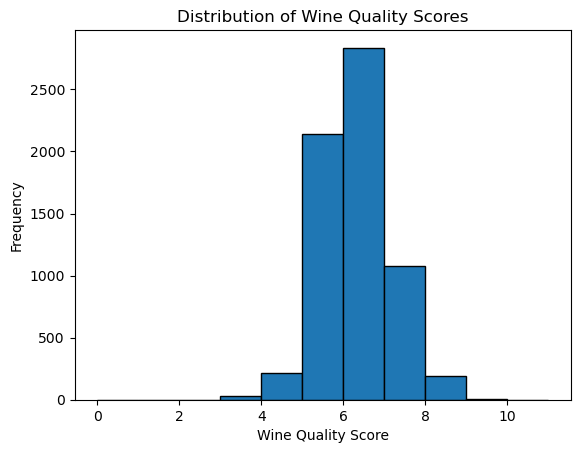

In [67]:
plt.hist(y, bins=range(0, 12), edgecolor='black')
plt.xlabel("Wine Quality Score")
plt.ylabel("Frequency")
plt.title("Distribution of Wine Quality Scores")
plt.show()

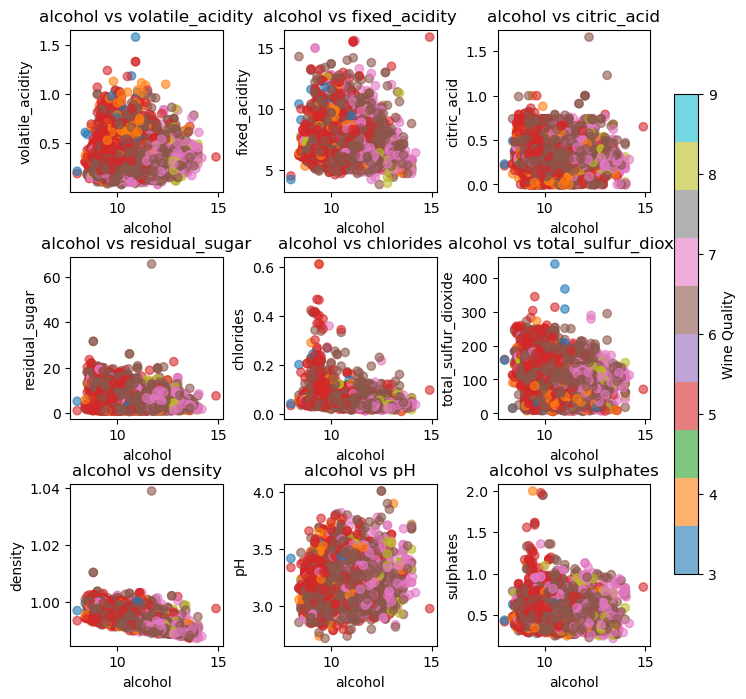

In [68]:
# Make a figure with 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

diff_y = ['volatile_acidity', 'fixed_acidity', 'citric_acid','residual_sugar', 
          'chlorides', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates']

# plot each subplot
for ax, y_name in zip(axes.flat, diff_y):
    sc = ax.scatter(X['alcohol'], X[y_name], c=y, cmap='tab10', alpha=0.6)
    ax.set_xlabel('alcohol')
    ax.set_ylabel(y_name)
    ax.set_title(f'alcohol vs {y_name}')

# adjust spacing and leave room for colorbar legend
fig.subplots_adjust(right=0.85, wspace=0.4, hspace=0.4)

# add colorbar on the right
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])
fig.colorbar(sc, cax=cbar_ax, label="Wine Quality")

plt.show()

In [69]:
plot_kwargs = {'cmap': 'viridis',
               'response_method': 'predict',
               'plot_method': 'pcolormesh',
               'shading': 'auto',
               'alpha': 0.5,
               'grid_resolution': 100}

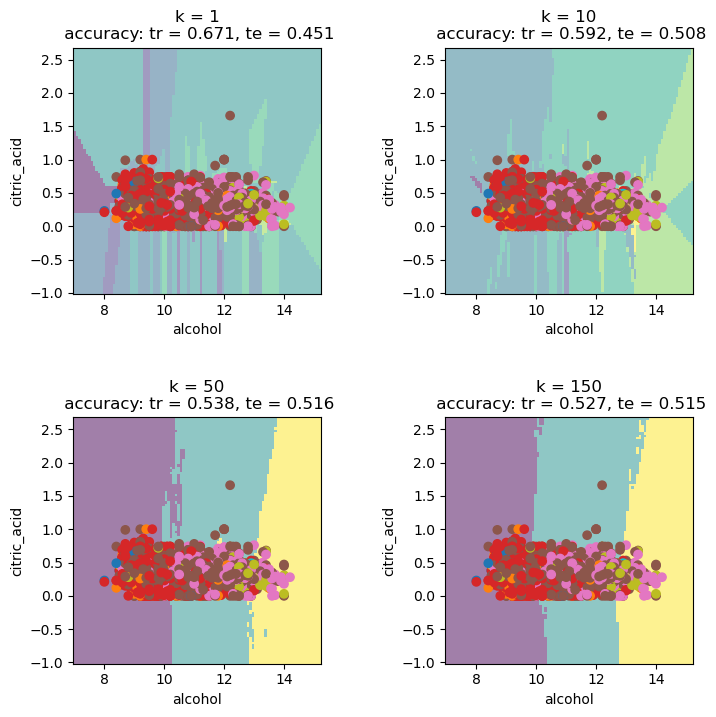

In [70]:
figure, axes = plt.subplots(2, 2, figsize=(8, 8))

plt.subplots_adjust(hspace=0.5, wspace=0.5)
label_enc = LabelEncoder()
y_vs = label_enc.fit_transform(y_tr)

#looking at alc and chlorides only
X_tr_2 = X_tr[['alcohol','citric_acid']]
X_te_2 = X_te[['alcohol','citric_acid']]

i = 0
for k in [1, 10, 50, 150]:
    knn_class = KNeighborsClassifier(n_neighbors=k)
    knn_class.fit(X_tr_2, y_tr)
    y_pred_tr = knn_class.predict(X_tr_2)
    y_pred_te = knn_class.predict(X_te_2)
    disp = DecisionBoundaryDisplay.from_estimator(knn_class, X_tr_2, 
                                                  ax = axes[i//2, i%2], **plot_kwargs)
    axes[i//2, i%2].scatter(X_tr_2['alcohol'], X_tr_2["citric_acid"],
                            c=y_vs, cmap='tab10')
    axes[i//2, i%2].set_title(
        f'k = {k}\n accuracy: tr = {accuracy_score(y_tr, y_pred_tr):.3f}, te = {accuracy_score(y_te, y_pred_te):.3f}')
    i += 1
    
plt.show()

Overfitting at smaller k values, begins to overfit at k=150. 
Since accuracies are at around 50%, we can tell this isn't a good classifier for the data.

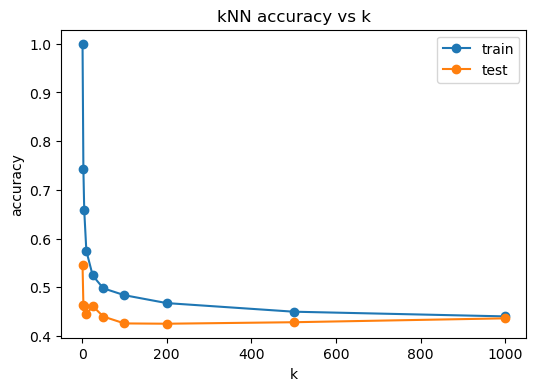

In [71]:

k_vals = [1, 3, 5, 10, 25, 50, 100, 200, 500, 1000]
train_acc = []
test_acc = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)   # preferably scaled full features
    train_acc.append(knn.score(X_tr, y_tr))
    test_acc.append(knn.score(X_te, y_te))

plt.figure(figsize=(6,4))
plt.plot(k_vals, train_acc, marker='o', label='train')
plt.plot(k_vals, test_acc, marker='o', label='test')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('kNN accuracy vs k')
plt.legend()
plt.show()

Can see underfitting at the start and overfitting at the end. Same conclusion as prev cell, where thr 50% acc tells us knn isnt the ideal choice for the classification of this dataset.

In [72]:
# feature scaling
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

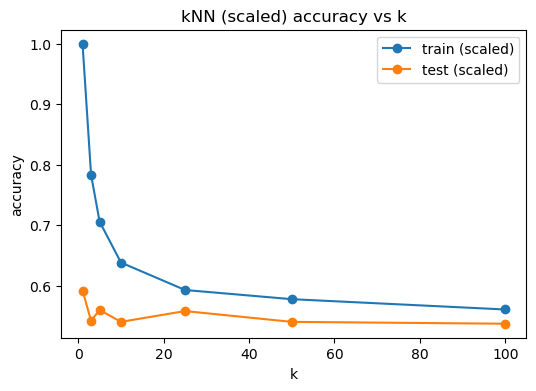

In [73]:
# Run kNN again after feature scaling

k_vals = [1, 3, 5, 10, 25, 50, 100]
train_acc_scaled = []
test_acc_scaled = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)   # X_tr is scaled now
    train_acc_scaled.append(knn.score(X_tr, y_tr))
    test_acc_scaled.append(knn.score(X_te, y_te))

plt.figure(figsize=(6,4))
plt.plot(k_vals, train_acc_scaled, marker='o', label='train (scaled)')
plt.plot(k_vals, test_acc_scaled, marker='o', label='test (scaled)')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('kNN (scaled) accuracy vs k')
plt.legend()
plt.show()

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial lo

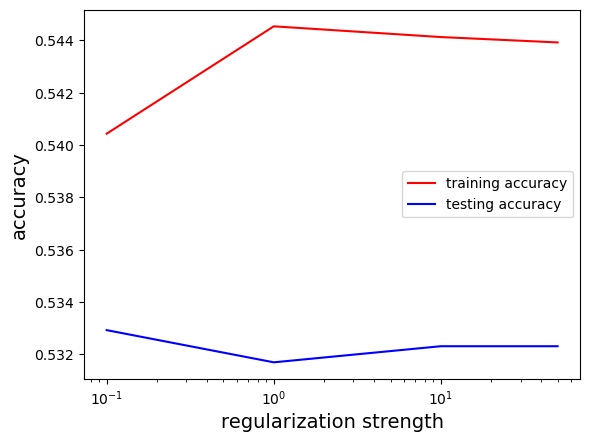

In [74]:
train_accuracies = []
test_accuracies = []
cs = [0.1, 1, 10, 50]

for c in cs:
    classifier = LogisticRegression(penalty='l1', C=c , solver='liblinear', fit_intercept=True, random_state=seed)
    classifier.fit(X_tr, y_tr)
    
    # log model training and test accuracies
    train_accuracies.append(accuracy_score(classifier.predict(X_tr), y_tr))
    test_accuracies.append(accuracy_score(classifier.predict(X_te), y_te))

fig, axes = plt.subplots()
axes.semilogx(cs, train_accuracies, color='red', label='training accuracy')
axes.semilogx(cs, test_accuracies, color='blue', label='testing accuracy')

axes.set_xlabel('regularization strength', fontsize=14)
axes.set_ylabel('accuracy', fontsize=14)

axes.legend()
plt.show()


Underfitting, as both accuracies are low. Regularization has little impact. 
Linear decision boundary not the move for this data set. 

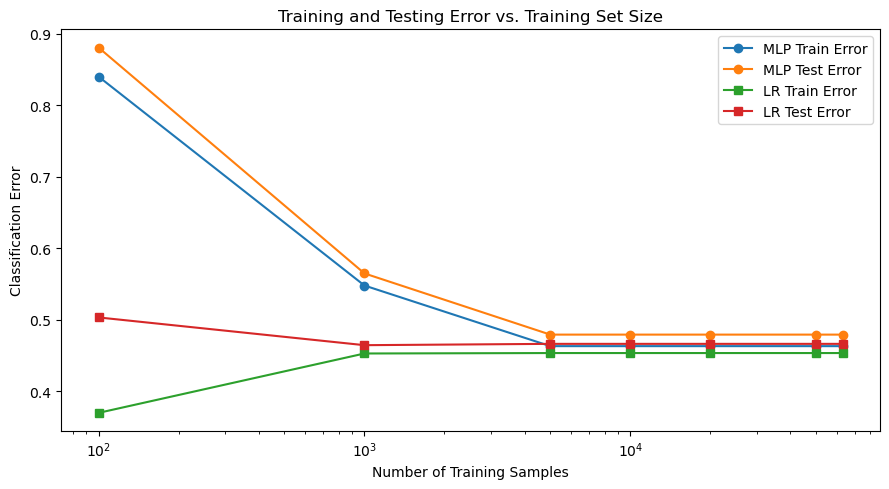

In [75]:
# learning curves w/ neural network
n_tr_values = [100, 1000, 5000, 10000, 20000, 50000, 63000]

mlp_train_errors = []
mlp_test_errors = []
lr_train_errors = []
lr_test_errors = []

for i in n_tr_values:
    X_train_sub = X_tr[:i]
    y_train_sub = y_tr[:i]

    mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                        solver='sgd', learning_rate_init=0.001
                        , max_iter=1000, early_stopping=True, random_state=seed)
    mlp.fit(X_train_sub, y_train_sub)
    mlp_train_errors.append(1 - mlp.score(X_train_sub, y_train_sub))
    mlp_test_errors.append(1 - mlp.score(X_te, y_te))

    lr = LogisticRegression(random_state=seed)
    lr.fit(X_train_sub, y_train_sub)
    lr_train_errors.append(1 - lr.score(X_train_sub, y_train_sub))
    lr_test_errors.append(1 - lr.score(X_te, y_te))

plt.figure(figsize=(9, 5))
plt.plot(n_tr_values, mlp_train_errors, marker='o', label='MLP Train Error')
plt.plot(n_tr_values, mlp_test_errors, marker='o', label='MLP Test Error')
plt.plot(n_tr_values, lr_train_errors, marker='s', label='LR Train Error')
plt.plot(n_tr_values, lr_test_errors, marker='s', label='LR Test Error')
plt.xscale('log')
plt.xlabel('Number of Training Samples')
plt.ylabel('Classification Error')
plt.title('Training and Testing Error vs. Training Set Size')
plt.legend()
plt.tight_layout()
plt.show()

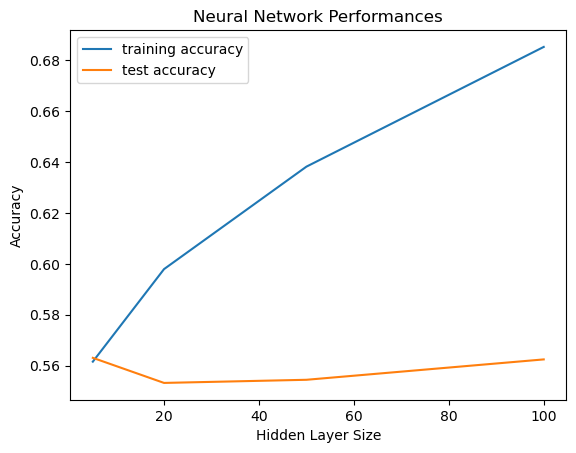

In [76]:
# experiment w/hidden size sweep

hidden_sizes = [5, 20, 50, 100]
train_accs = []
test_accs = []

for h in hidden_sizes:
    nn = MLPClassifier(hidden_layer_sizes=(h,), activation='relu', max_iter=1000, random_state=seed)

    nn.fit(X_tr, y_tr)

    train_acc = accuracy_score(nn.predict(X_tr), y_tr)
    test_acc = accuracy_score(nn.predict(X_te), y_te)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

# plot
plt.plot(hidden_sizes, train_accs, label="training accuracy")
plt.plot(hidden_sizes, test_accs, label="test accuracy")

plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Neural Network Performances")
plt.legend()
plt.show()


Random Forest Accuracy: 0.6658


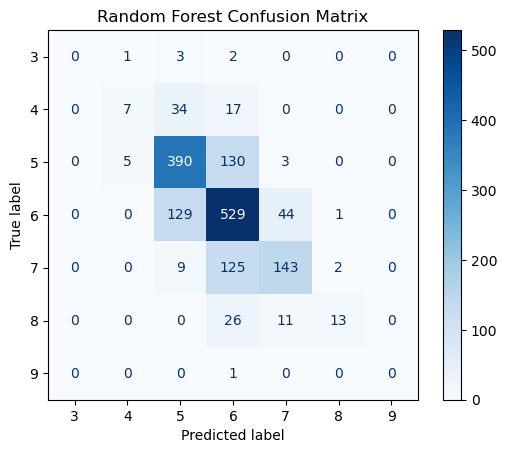

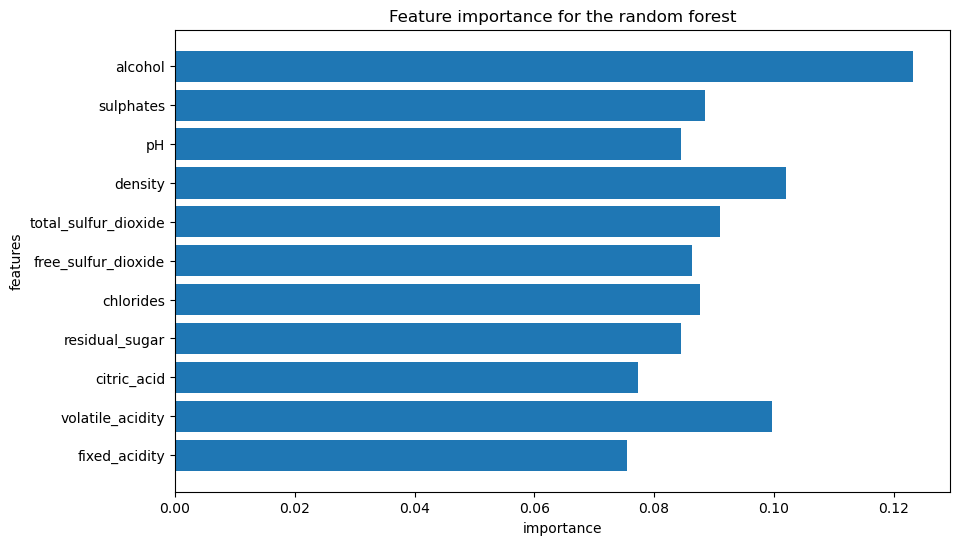

In [77]:
#add random forest classifier
#edit n_estimators to the number of trees
randomforest = RandomForestClassifier(n_estimators=100, random_state=seed)
#train the data on vars
randomforest.fit(X_tr, y_tr)
#training values
prediction = randomforest.predict(X_te)
#actual values
accuracy = accuracy_score(y_te, prediction)

print(f"Random Forest Accuracy: {accuracy:.4f}")

#confusion matrix shows how well each class was predicted
disp = ConfusionMatrixDisplay.from_estimator(randomforest, X_te, y_te, cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

#second layout the important features
important = randomforest.feature_importances_
features = wine_quality.data.features.columns

plt.figure(figsize=(10, 6))
plt.barh(features, important)
plt.xlabel("importance")
plt.ylabel("features")
plt.title("Feature importance for the random forest")
plt.show()

kNN best: 0.5624615384615385
Logistic best: 0.5329230769230769
Neural Net best: 0.563076923076923
Random Forest: 0.6658461538461539


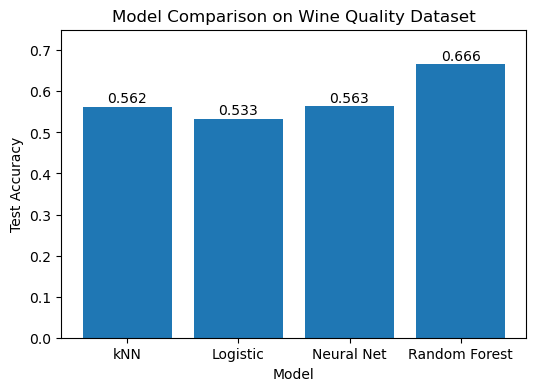

In [ ]:
import matplotlib.pyplot as plt

# kNN
knn_best = max(test_acc) if isinstance(test_acc, list) else test_acc

# logistic
logistic_best = max(test_accuracies)

# neural net
mlp_best = max(test_accs)

# random forest
rf_best = accuracy

# print to verify
print("kNN best:", knn_best)
print("Logistic best:", logistic_best)
print("Neural Net best:", mlp_best)
print("Random Forest:", rf_best)

# bar chart
models = ['kNN', 'Logistic', 'Neural Net', 'Random Forest']
test_acc_values = [knn_best, logistic_best, mlp_best, rf_best]

plt.figure(figsize=(6,4))
plt.bar(models, test_acc_values)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on Wine Quality Dataset")

# labels
for i, v in enumerate(test_acc_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.ylim(0, 0.75)
plt.show()